Found 202 files belonging to 2 classes.
Using 162 files for training.
Found 202 files belonging to 2 classes.
Using 40 files for validation.
Classes: ['defective', 'non-defective']
Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 410ms/step - accuracy: 0.4321 - loss: 0.7719 - val_accuracy: 0.4500 - val_loss: 0.7251 - learning_rate: 1.0000e-04
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 279ms/step - accuracy: 0.5370 - loss: 0.7045 - val_accuracy: 0.4000 - val_loss: 0.6780 - learning_rate: 1.0000e-04
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 292ms/step - accuracy: 0.5926 - loss: 0.6561 - val_accuracy: 0.6750 - val_loss: 0.6491 - learning_rate: 1.0000e-04
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 276ms/step - accuracy: 0.6605 - loss: 0.6311 - val_accuracy: 0.7750 - val_loss: 0.6287 - learning_rate: 1.0000e-04
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 271ms/step - accuracy: 0.6975 - loss: 0.5859 - val_accuracy: 0.7250 - val_loss: 0.6121 - learning_rate: 1.0000e-04
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3

Model saved successfully.


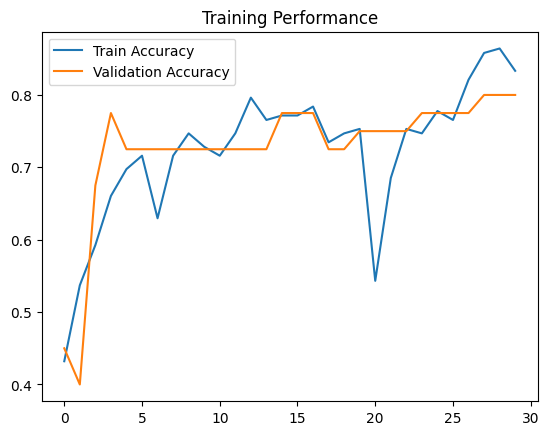

In [ ]:


import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
import matplotlib.pyplot as plt
import numpy as np


IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS_HEAD = 20
EPOCHS_FINE = 10
DATA_PATH = "data/train_data"

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
])


base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)

outputs = layers.Dense(2, activation="softmax")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3
    )
]


history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks
)


base_model.trainable = True

# Freeze lower layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=callbacks
)


model.save("washer_defect_model.keras")
model.save("washer_defect_model.h5")
print("Model saved successfully.")


acc = history1.history["accuracy"] + history2.history["accuracy"]
val_acc = history1.history["val_accuracy"] + history2.history["val_accuracy"]

plt.plot(acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.legend()
plt.title("Training Performance")
plt.show()

In [2]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    pred = model.predict(images, verbose=0)
    pred = np.argmax(pred, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

[[12  8]
 [ 0 20]]
              precision    recall  f1-score   support

           0       1.00      0.60      0.75        20
           1       0.71      1.00      0.83        20

    accuracy                           0.80        40
   macro avg       0.86      0.80      0.79        40
weighted avg       0.86      0.80      0.79        40

